<a href="https://colab.research.google.com/github/hemidovaqil/turboaz-ml-analysis/blob/main/1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
df = pd.read_csv("house_sale.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100775, 51)


,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,...,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,...,7 / 9,4.0,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,...,NaN,4.0,90 m²,1.3 sot,var,yoxdur,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,...,NaN,3.0,60 m²,0.1 sot,var,var,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/alqi-satqi?page=250,/items/4647811,2024-10-05 22:07:37.60613+00,95000.0,AZN,Qaraçuxur q.,130 m²,"Bakı, dünən 23:55",bakı,...,NaN,NaN,130 m²,NaN,var,var,var,5db56980-05cc-4925-b55b-f58fb3f4d2b6,/items/4647811,Suraxanı r.* Qaraçuxur q.
4,22d840df-9283-4112-bc71-7432511fc776,/alqi-satqi?page=250,/items/4638863,2024-10-05 22:07:37.60613+00,220000.0,AZN,Əhmədli m.,"3 otaqlı, 100 m², 15/16 mərtəbə","Bakı, dünən 23:52",bakı,...,15 / 16,3.0,100 m²,NaN,var,var,NaN,d71cf9a9-86dd-4162-b540-6252a8659a09,/items/4638863,Əhmədli m.* Xalqlar Dostluğu m.* Xətai r.* Əhm...


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("house_sale.csv")

print("Dataset shape:", df.shape)
print(df.columns.tolist())

Dataset shape: (100775, 51)
['id_x', 'rel_url', 'estate_rel_url_x', 'datetime_scrape_x', 'price', 'currency_x', 'location', 'attributes', 'city_when', 'city', 'day_x', 'hour_x', 'repair', 'vip', 'featured', 'products_label', 'bill_of_sale', 'mortgage', 'img_url', 'id_y', 'estate_id', 'estate_rel_url_y', 'datetime_scrape_y', 'description', 'unit_price', 'total_price', 'currency_y', 'owner_name', 'owner_title', 'shop_name', 'shop_title', 'address', 'lat', 'lng', 'updated', 'views', 'day_y', 'hour_y', 'estate_details_id_x', 'Binanın növü', 'Kateqoriya', 'Mərtəbə', 'Otaq sayı', 'Sahə', 'Torpaq sahəsi', 'Təmir', 'Çıxarış', 'İpoteka', 'estate_details_id_y', 'estate_rel_url', 'extra_info']


In [5]:
print("Columns:")
print(df.columns.tolist())

Columns:
['id_x', 'rel_url', 'estate_rel_url_x', 'datetime_scrape_x', 'price', 'currency_x', 'location', 'attributes', 'city_when', 'city', 'day_x', 'hour_x', 'repair', 'vip', 'featured', 'products_label', 'bill_of_sale', 'mortgage', 'img_url', 'id_y', 'estate_id', 'estate_rel_url_y', 'datetime_scrape_y', 'description', 'unit_price', 'total_price', 'currency_y', 'owner_name', 'owner_title', 'shop_name', 'shop_title', 'address', 'lat', 'lng', 'updated', 'views', 'day_y', 'hour_y', 'estate_details_id_x', 'Binanın növü', 'Kateqoriya', 'Mərtəbə', 'Otaq sayı', 'Sahə', 'Torpaq sahəsi', 'Təmir', 'Çıxarış', 'İpoteka', 'estate_details_id_y', 'estate_rel_url', 'extra_info']


In [6]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100775 entries, 0 to 100774
Data columns (total 51 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id_x                 100775 non-null  object 
 1   rel_url              100775 non-null  object 
 2   estate_rel_url_x     100775 non-null  object 
 3   datetime_scrape_x    100775 non-null  object 
 4   price                100775 non-null  float64
 5   currency_x           100775 non-null  object 
 6   location             100775 non-null  object 
 7   attributes           100775 non-null  object 
 8   city_when            100775 non-null  object 
 9   city                 100775 non-null  object 
 10  day_x                100775 non-null  object 
 11  hour_x               100775 non-null  object 
 12  repair               81612 non-null   object 
 13  vip                  8596 non-null    object 
 14  featured             3149 non-null    object 
 

In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
id_x                        0
rel_url                     0
estate_rel_url_x            0
datetime_scrape_x           0
price                       0
currency_x                  0
location                    0
attributes                  0
city_when                   0
city                        0
day_x                       0
hour_x                      0
repair                  19163
vip                     92179
featured                97626
products_label          28145
bill_of_sale            21210
mortgage                67836
img_url                     0
id_y                        0
estate_id                   0
estate_rel_url_y            0
datetime_scrape_y           0
description               265
unit_price              24779
total_price                 0
currency_y                  0
owner_name                657
owner_title               657
shop_name               28757
shop_title              28757
address                     0
lat                     

In [8]:
df.describe(include="all")

,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,...,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
count,100775,100775,100775,100775,1.007750e+05,100775,100775,100775,100775,100775,...,75996,91363.000000,100775,15571,94774,100775,32939,100775,100775,100775
unique,100775,411,64454,36,NaN,1,142,21347,1504,8,...,392,NaN,1804,188,2,2,1,100775,64454,3000
top,e85db6c0-141d-44a3-a078-dcb4a4641091,/alqi-satqi?page=267,/items/4582627,2024-10-09 04:58:40.151251+00,NaN,AZN,Nəriman Nərimanov m.,"4 otaqlı, 160 m²","Bakı, dünən 12:26",bakı,...,5 / 5,NaN,100 m²,3 sot,var,var,var,1af4df10-8bfe-4d29-8964-9d8533cd3883,/items/4582627,Xəzər r.* Mərdəkan q.
freq,1,691,17,5322,NaN,100775,5390,593,218,100436,...,1989,NaN,3488,1759,81612,79565,32939,1,17,4825
mean,NaN,NaN,NaN,NaN,3.423557e+05,NaN,NaN,NaN,NaN,NaN,...,NaN,3.133468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,2.042627e+06,NaN,NaN,NaN,NaN,NaN,...,NaN,1.372981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.100000e+01,NaN,NaN,NaN,NaN,NaN,...,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,1.450000e+05,NaN,NaN,NaN,NaN,NaN,...,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,2.180000e+05,NaN,NaN,NaN,NaN,NaN,...,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,3.380000e+05,NaN,NaN,NaN,NaN,NaN,...,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print(df.columns.tolist())

['id_x', 'rel_url', 'estate_rel_url_x', 'datetime_scrape_x', 'price', 'currency_x', 'location', 'attributes', 'city_when', 'city', 'day_x', 'hour_x', 'repair', 'vip', 'featured', 'products_label', 'bill_of_sale', 'mortgage', 'img_url', 'id_y', 'estate_id', 'estate_rel_url_y', 'datetime_scrape_y', 'description', 'unit_price', 'total_price', 'currency_y', 'owner_name', 'owner_title', 'shop_name', 'shop_title', 'address', 'lat', 'lng', 'updated', 'views', 'day_y', 'hour_y', 'estate_details_id_x', 'Binanın növü', 'Kateqoriya', 'Mərtəbə', 'Otaq sayı', 'Sahə', 'Torpaq sahəsi', 'Təmir', 'Çıxarış', 'İpoteka', 'estate_details_id_y', 'estate_rel_url', 'extra_info']


In [10]:
target = "price"

print("Target variable:", target)
print("Target data type:", df[target].dtype)

Target variable: price
Target data type: float64


In [11]:
print(df[target].describe())

count    1.007750e+05
mean     3.423557e+05
std      2.042627e+06
min      1.100000e+01
25%      1.450000e+05
50%      2.180000e+05
75%      3.380000e+05
max      6.000000e+08
Name: price, dtype: float64


In [7]:
print(df.columns.tolist())

['id_x', 'rel_url', 'estate_rel_url_x', 'datetime_scrape_x', 'price', 'currency_x', 'location', 'attributes', 'city_when', 'city', 'day_x', 'hour_x', 'repair', 'vip', 'featured', 'products_label', 'bill_of_sale', 'mortgage', 'img_url', 'id_y', 'estate_id', 'estate_rel_url_y', 'datetime_scrape_y', 'description', 'unit_price', 'total_price', 'currency_y', 'owner_name', 'owner_title', 'shop_name', 'shop_title', 'address', 'lat', 'lng', 'updated', 'views', 'day_y', 'hour_y', 'estate_details_id_x', 'Binanın növü', 'Kateqoriya', 'Mərtəbə', 'Otaq sayı', 'Sahə', 'Torpaq sahəsi', 'Təmir', 'Çıxarış', 'İpoteka', 'estate_details_id_y', 'estate_rel_url', 'extra_info']


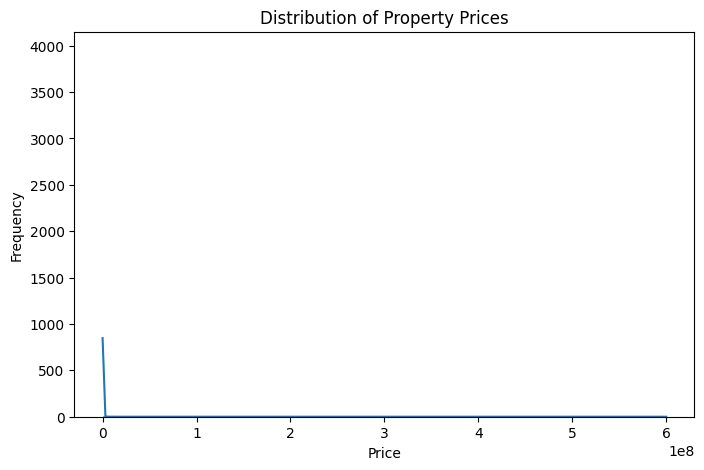

In [8]:
target = "price"

plt.figure(figsize=(8, 5))
sns.histplot(df[target], kde=True)

plt.title("Distribution of Property Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

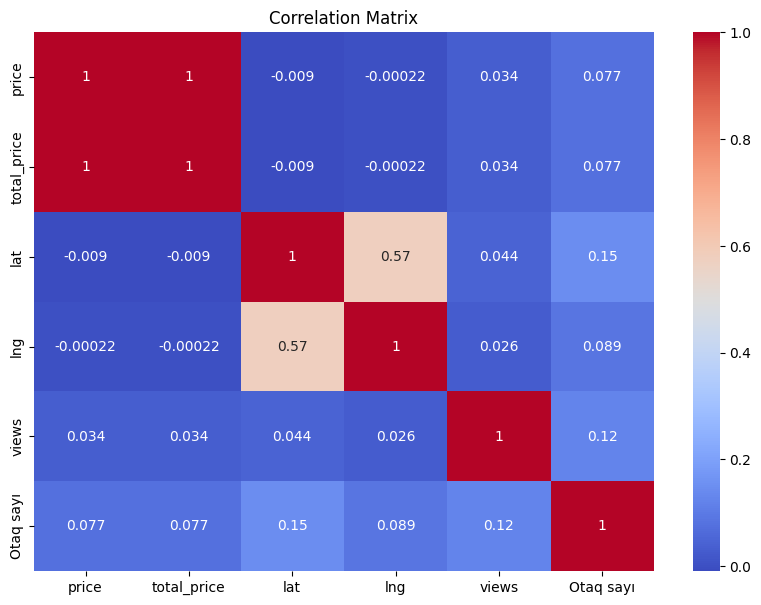

In [9]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [10]:
target = "price"

X = df.drop(columns=[target])
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (100775, 50)
Target shape: (100775,)


## Problem Formulation

The goal of this project is to predict the selling price of real estate properties listed on Bina.az.

The business problem is to estimate a reasonable property price based on available characteristics such as location, number of rooms, area, floor, building type, repair status, and other property features.

Target variable: price.

This is a supervised regression problem because the target variable is a continuous numerical value.

The main success metrics will be MAE, RMSE, and R². Lower MAE and RMSE indicate better prediction accuracy, while a higher R² indicates that the model explains more of the variation in property prices.

## Project Objective

The objective is to build and compare machine learning regression models that can accurately predict property prices using the available Bina.az property features.

The final model will be selected based on its performance on unseen data using appropriate regression metrics.